# 🧩 Reto de aplicación — Preprocesamiento y Ensemble (SOLUCIÓN)
### Dataset: Tips 🍽️

⚠️ **Esta es la versión con las soluciones resueltas — es para ti (la coder), no para repartir a tus compañeros.**
El notebook que ellos reciben es `reto_notebook_bloque3_tips_v2.ipynb`, con los mismos pasos pero en blanco (`# TODO: Implementar aquí`).

Incluye Random Forest y XGBoost, para tener ya la comparación lista de cara al debate del Bloque 4.


## 0. Setup — instala e importa las librerías necesarias

In [52]:
# Si estás en Google Colab, descomenta la siguiente línea:
# !pip install xgboost -q

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier


## 1. Punto de partida: el modelo base

Carga el dataset, trata outliers en `total_bill`, crea la feature `tip_pct` (el % que representa la
propina sobre la cuenta) y entrena un Random Forest para predecir `time` (Lunch/Dinner).


In [53]:
df = sns.load_dataset('tips')
df_raw = df.copy()   # copia intacta, nunca la tocamos
print("Shape:", df.shape)
df.head()

Shape: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [54]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [55]:
# Outliers en total_bill (tratamiento base)
Q1 = df['total_bill'].quantile(0.25)
Q3 = df['total_bill'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df['total_bill'] = df['total_bill'].clip(lower_bound, upper_bound)

# Feature engineering base: % de propina sobre la cuenta
df['tip_pct'] = df['tip'] / df['total_bill']

df.head()


,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059447
1,10.34,1.66,Male,No,Sun,Dinner,3,0.160542
2,21.01,3.50,Male,No,Sun,Dinner,3,0.166587
3,23.68,3.31,Male,No,Sun,Dinner,2,0.139780
4,24.59,3.61,Female,No,Sun,Dinner,4,0.146808


In [56]:
num_cols_base = ['total_bill', 'tip', 'size', 'tip_pct']
cat_cols = ['sex', 'smoker', 'day']

X_base = df[num_cols_base + cat_cols]
y = df['time']

X_train, X_test, y_train, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor_base = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_cols_base),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols)
])

rf_base_pipeline = Pipeline([
    ('preprocessor', preprocessor_base),
    ('model', RandomForestClassifier(n_estimators=200, random_state=42))
])

rf_base_pipeline.fit(X_train, y_train)
base_preds = rf_base_pipeline.predict(X_test)
base_accuracy = accuracy_score(y_test, base_preds)

print(f"✅ Accuracy del modelo BASE (Random Forest): {base_accuracy:.3f}")
print(classification_report(y_test, base_preds))


✅ Accuracy del modelo BASE (Random Forest): 0.918
              precision    recall  f1-score   support

      Dinner       0.97      0.91      0.94        35
       Lunch       0.81      0.93      0.87        14

    accuracy                           0.92        49
   macro avg       0.89      0.92      0.90        49
weighted avg       0.92      0.92      0.92        49



---
## 🧩 A partir de aquí, el reto — resuelto

### Paso 1 — Outliers en `tip` (IQR)

>> Si al re-ejecutar la celda, los outliers dan 0, lo mejor es trabajar con una copia df_raw

Outliers detectados en tip: 9
Límites válidos: [-0.34, 5.91]


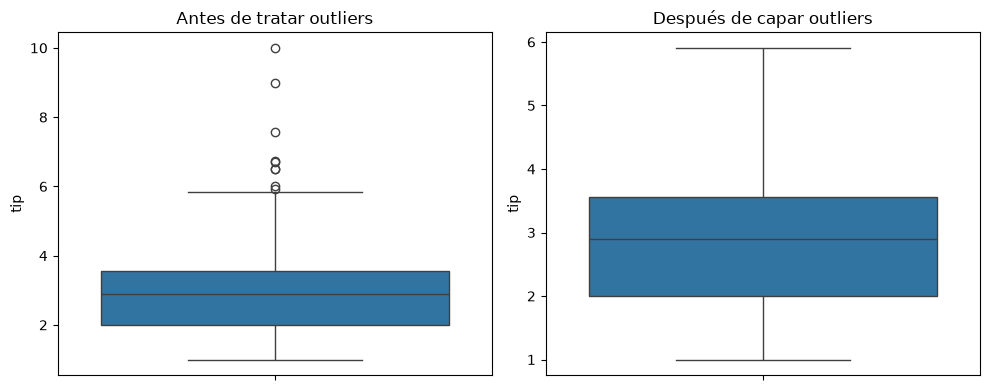

In [63]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=df_raw['tip'], ax=ax[0])
ax[0].set_title('Antes de tratar outliers')

outlier_col = 'tip'

Q1 = df_raw[outlier_col].quantile(0.25)
Q3 = df_raw[outlier_col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_detectados = df_raw[(df_raw[outlier_col] < lower_bound) | (df_raw[outlier_col] > upper_bound)]
print(f"Outliers detectados en {outlier_col}: {len(outliers_detectados)}")
print(f"Límites válidos: [{lower_bound:.2f}, {upper_bound:.2f}]")

df[outlier_col] = df[outlier_col].clip(lower_bound, upper_bound)

sns.boxplot(y=df['tip'], ax=ax[1])
ax[1].set_title('Después de capar outliers')
plt.tight_layout()
plt.show()

### Paso 2 — Nueva feature: `bill_per_person`

In [58]:
df['bill_per_person'] = df['total_bill'] / df['size']
mi_feature_nueva = 'bill_per_person'

df[['total_bill', 'size', 'bill_per_person']].head()


,total_bill,size,bill_per_person
0,16.99,2,8.495000
1,10.34,3,3.446667
2,21.01,3,7.003333
3,23.68,2,11.840000
4,24.59,4,6.147500


### Paso 3 — Random Forest con la nueva feature

In [59]:
num_cols_reto = num_cols_base + [mi_feature_nueva]
X_reto = df[num_cols_reto + cat_cols]

X_train_reto, X_test_reto, y_train_reto, y_test_reto = train_test_split(
    X_reto, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor_reto = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_cols_reto),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols)
])

rf_reto_pipeline = Pipeline([
    ('preprocessor', preprocessor_reto),
    ('model', RandomForestClassifier(n_estimators=200, random_state=42))
])

rf_reto_pipeline.fit(X_train_reto, y_train_reto)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['Dinner','Lunch']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['total_bill','tip','size',...,'sex','smoker','day']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaini

### Paso 4 — Random Forest reto vs. base

In [60]:
reto_preds = rf_reto_pipeline.predict(X_test_reto)
reto_accuracy = accuracy_score(y_test_reto, reto_preds)

print(f"Accuracy RF base:  {base_accuracy:.3f}")
print(f"Accuracy RF reto:  {reto_accuracy:.3f}")
print(f"Diferencia: {reto_accuracy - base_accuracy:+.3f}")
print(classification_report(y_test_reto, reto_preds))


Accuracy RF base:  0.918
Accuracy RF reto:  0.918
Diferencia: +0.000
              precision    recall  f1-score   support

      Dinner       0.97      0.91      0.94        35
       Lunch       0.81      0.93      0.87        14

    accuracy                           0.92        49
   macro avg       0.89      0.92      0.90        49
weighted avg       0.92      0.92      0.92        49



### Paso 5 — XGBoost con la misma feature nueva

Usamos `clone(preprocessor_reto)` para tener un preprocesador nuevo sin entrenar (si reutilizáramos
el mismo objeto ya ajustado, el segundo `.fit()` pisaría el ajuste del primero).


In [61]:
le = LabelEncoder()
y_train_reto_enc = le.fit_transform(y_train_reto)
y_test_reto_enc = le.transform(y_test_reto)

preprocessor_xgb = clone(preprocessor_reto)

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor_xgb),
    ('model', XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        random_state=42,
        eval_metric='logloss'
    ))
])

xgb_pipeline.fit(X_train_reto, y_train_reto_enc)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['total_bill','tip','size',...,'sex','smoker','day']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns tha

### Paso 6 — Random Forest vs. XGBoost

In [62]:
xgb_preds = xgb_pipeline.predict(X_test_reto)
xgb_accuracy = accuracy_score(y_test_reto_enc, xgb_preds)

print(f"Accuracy RF base:      {base_accuracy:.3f}")
print(f"Accuracy RF reto:      {reto_accuracy:.3f}")
print(f"Accuracy XGBoost reto: {xgb_accuracy:.3f}")
print()
print(classification_report(y_test_reto_enc, xgb_preds, target_names=le.classes_))


Accuracy RF base:      0.918
Accuracy RF reto:      0.918
Accuracy XGBoost reto: 0.939

              precision    recall  f1-score   support

      Dinner       1.00      0.91      0.96        35
       Lunch       0.82      1.00      0.90        14

    accuracy                           0.94        49
   macro avg       0.91      0.96      0.93        49
weighted avg       0.95      0.94      0.94        49



---
## 💬 Notas para el Bloque 4 (a partir de esta solución)

- Con `tip` como columna de outliers, `bill_per_person` como feature nueva, y comparando RF vs. XGBoost,
  las diferencias de accuracy suelen ser pequeñas — normal en un dataset de 244 filas, donde XGBoost
  no tiene tantos datos como para lucirse frente a Random Forest.
- Si alguna pareja ve a XGBoost claramente por debajo del Random Forest, es un buen momento para recordar
  que XGBoost tiene más hiperparámetros y es más sensible a ellos — con los valores por defecto puede no
  rendir a su máximo potencial en datasets pequeños.
- Recordatorio para el debate: la clase `Lunch` (minoritaria) suele seguir siendo la más débil en ambos
  modelos — el cambio de algoritmo no arregla por sí solo un problema de desbalance de clases.
- Pregunta de cierre potente: *"¿Cambiaría vuestra respuesta sobre qué modelo es mejor si el dataset
  tuviera 100.000 filas en vez de 244?"*
